# EDA Completo — Customer Support Ticket Dataset

Este notebook dá continuidade ao EDA inicial feito no TP1. Além das etapas que já existiam, ele inclui a análise multivariada, a identificação de outliers e anomalias, os testes de hipótese formais e as conclusões. Também incorpora os ajustes apontados no feedback do TP1: o dicionário de dados com o significado de cada coluna, as verificações de qualidade mais detalhadas (categorias inconsistentes, textos vazios, valores impossíveis e erros de preenchimento), a variância das variáveis numéricas, a frequência relativa das categóricas e uma fundamentação melhor das hipóteses.

As seções seguem a numeração do enunciado do TP2:

- Documentação do dataset
- 1.1 Compreensão do problema e do dataset
- 1.2 Inspeção inicial
- 1.3 Verificação da qualidade dos dados
- 1.4 Limpeza e preparação dos dados
- 1.5 Análise Univariada
- 1.6 Análise Multivariada (inclui as hipóteses e os testes formais)
- 1.7 Identificação de Outliers e Anomalias
- 1.8 Documentação do EDA e conclusões

## Documentação do Dataset — Customer Support Ticket Dataset

### a. Fonte (origem do dataset)

O dataset utilizado neste trabalho é o **"Customer Support Ticket Dataset"**, disponibilizado publicamente no Kaggle, no endereço:

`https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset/data`

Trata-se de um conjunto de dados que reúne tickets de suporte técnico ao cliente relacionados a diversos produtos de tecnologia. Por questão de privacidade, os e-mails utilizam domínios genéricos (`@example.com`, `@example.net`, `@example.org`), indicando que os dados foram tratados/mascarados antes da publicação.

### b. Principais características

- **Volume**: 8.469 registros (tickets) e 17 colunas (atributos)
- **Unidade de análise**: cada linha representa um ticket de suporte único, identificado por `Ticket ID`
- **Natureza mista**: combina variáveis categóricas (gênero, tipo de ticket, canal, prioridade), numéricas (idade, satisfação), textuais (descrição, resolução) e temporais (datas de compra, primeira resposta e resolução)
- **Domínio de aplicação**: suporte técnico a produtos de tecnologia, cobrindo problemas de hardware, bugs de software, falhas de rede, acesso a contas, perda de dados, entre outros

### c. Dicionário de dados

| Coluna | Tipo | Significado | Exemplo | Observações |
|---|---|---|---|---|
| `Ticket ID` | Numérica (identificador) | Número único que identifica o ticket | `1` | Não tem significado estatístico, serve apenas como chave |
| `Customer Name` | Texto (PII) | Nome do cliente que abriu o ticket | `Marisa Obrien` | Dado pessoal fictício. Não é usado na análise |
| `Customer Email` | Texto (PII) | E-mail do cliente | `carrollallison@example.com` | Dado pessoal mascarado. Não é usado na análise |
| `Customer Age` | Numérica discreta | Idade do cliente, em anos | `32` | Faixa esperada de adultos |
| `Customer Gender` | Categórica nominal | Gênero informado pelo cliente | `Male`, `Female`, `Other` | 3 categorias |
| `Product Purchased` | Categórica nominal | Produto de tecnologia sobre o qual o ticket foi aberto | `GoPro Hero` | 42 produtos diferentes |
| `Date of Purchase` | Data | Data em que o cliente comprou o produto | `2021-03-22` | Vem como texto no CSV |
| `Ticket Type` | Categórica nominal | Natureza da solicitação, ou seja, a intenção geral do cliente | `Technical issue` | 5 categorias. Candidata a variável-alvo |
| `Ticket Subject` | Categórica nominal | Assunto específico do ticket | `Product setup` | 16 categorias. Candidata a variável-alvo |
| `Ticket Description` | Texto livre | Descrição do problema escrita pelo cliente | `I'm having an issue with the {product_purchased}...` | Contém marcadores de template não substituídos (ver 1.3) |
| `Ticket Status` | Categórica nominal | Situação atual do ticket | `Open`, `Pending Customer Response`, `Closed` | Determina quais colunas de resolução estão preenchidas |
| `Resolution` | Texto livre | Texto da solução registrada pelo atendente | `Case maybe show recently my computer follow.` | Só existe para tickets `Closed` |
| `Ticket Priority` | Categórica ordinal | Urgência atribuída ao ticket | `Low` < `Medium` < `High` < `Critical` | 4 níveis |
| `Ticket Channel` | Categórica nominal | Canal pelo qual o cliente abriu o ticket | `Email`, `Phone`, `Chat`, `Social media` | 4 canais |
| `First Response Time` | Data e hora | **Momento** em que o ticket recebeu a primeira resposta | `2023-06-01 12:15:36` | Apesar do nome, é um timestamp e não uma duração. Vazio para tickets `Open` |
| `Time to Resolution` | Data e hora | **Momento** em que o ticket foi resolvido | `2023-06-01 18:05:38` | Também é um timestamp. Só existe para tickets `Closed` |
| `Customer Satisfaction Rating` | Numérica ordinal | Nota de satisfação dada pelo cliente após o atendimento | `1` a `5` | Só existe para tickets `Closed` |

### d. Motivo de escolha do dataset

1. **Diversidade de variáveis para EDA**: combina dados categóricos, numéricos, textuais e temporais, permitindo uma análise exploratória completa.
2. **Variável-alvo natural**: `Ticket Type` e `Ticket Subject` representam a **intenção do cliente** ao abrir um ticket, que é o problema central do sistema de atendimento com IA que será construído nos próximos TPs.
3. **Aderência ao caso de uso do projeto**: a API do projeto simula um sistema de atendimento ao cliente, e um dataset de tickets de suporte é o insumo mais direto para esse domínio.
4. **Tamanho adequado**: cerca de 8.500 registros é suficiente para análises estatísticas, mas ainda leve para processamento local.

## 1.1 Compreensão do problema e do dataset

O dataset representa tickets de suporte técnico ao cliente. O problema de negócio é entender **por que** os clientes abrem tickets, ou seja, identificar a **intenção** por trás de cada solicitação (`Ticket Type` / `Ticket Subject`) a partir de atributos do cliente, do produto e da descrição do problema. Nos próximos TPs, essa intenção será prevista por um modelo de ML exposto pela rota `/predictions/predict` da API.

As perguntas que o EDA precisa responder são:

- Os dados têm qualidade suficiente para treinar um modelo? Há erros, inconsistências ou valores impossíveis?
- Como cada variável se distribui?
- Existe relação entre a intenção do cliente e as demais variáveis (idade, produto, canal, prioridade, satisfação, texto)?
- Há outliers ou anomalias que precisam ser tratados?

Classificação das variáveis:

| Grupo | Colunas |
|---|---|
| Numéricas | `Customer Age`, `Customer Satisfaction Rating` (ordinal) e as derivadas criadas na etapa 1.4 |
| Categóricas | `Customer Gender`, `Product Purchased`, `Ticket Type`, `Ticket Subject`, `Ticket Status`, `Ticket Priority`, `Ticket Channel` |
| Textuais | `Ticket Description`, `Resolution` |
| Temporais | `Date of Purchase`, `First Response Time`, `Time to Resolution` |
| Identificadores e PII | `Ticket ID`, `Customer Name`, `Customer Email` |

In [1]:
import re
import difflib
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

df = pd.read_csv("../data/customer_support_tickets.csv")

## 1.2 Inspeção inicial

In [2]:
df.shape

(8469, 17)

In [3]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

**Observações:**

- São 8.469 linhas e 17 colunas, como descrito na documentação.
- Apenas `Ticket ID`, `Customer Age` (inteiros) e `Customer Satisfaction Rating` (float) foram lidas como numéricas. A nota de satisfação aparece como `float` porque tem valores vazios.
- As três colunas de data (`Date of Purchase`, `First Response Time` e `Time to Resolution`) foram lidas como texto e precisam ser convertidas para `datetime`.
- `Resolution`, `First Response Time`, `Time to Resolution` e `Customer Satisfaction Rating` têm menos valores não nulos que as demais, o que é investigado na etapa 1.3.

In [5]:
df.describe()

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.000000,8469.000000,2769.000000
mean,4235.000000,44.026804,2.991333
std,2444.934048,15.296112,1.407016
min,1.000000,18.000000,1.000000
25%,2118.000000,31.000000,2.000000
50%,4235.000000,44.000000,3.000000
75%,6352.000000,57.000000,4.000000
max,8469.000000,70.000000,5.000000


In [6]:
colunas_texto = ["Customer Name", "Customer Email", "Customer Gender", "Product Purchased",
                 "Ticket Type", "Ticket Subject", "Ticket Description", "Ticket Status",
                 "Resolution", "Ticket Priority", "Ticket Channel"]

df[colunas_texto].describe().T

,count,unique,top,freq
Customer Name,8469,8028,Michael Garcia,5
Customer Email,8469,8320,asmith@example.com,4
Customer Gender,8469,3,Male,2896
Product Purchased,8469,42,Canon EOS,240
Ticket Type,8469,5,Refund request,1752
Ticket Subject,8469,16,Refund request,576
Ticket Description,8469,8077,I'm having an issue with the {product_purchase...,25
Ticket Status,8469,3,Pending Customer Response,2881
Resolution,2769,2769,Case maybe show recently my computer follow.,1
Ticket Priority,8469,4,Medium,2192


**Observações:**

- `Customer Age` vai de 18 a 70 anos, com média (44,0) praticamente igual à mediana (44). Não há idades negativas ou absurdas à primeira vista.
- `Customer Satisfaction Rating` vai de 1 a 5, dentro da escala esperada, com média próxima de 3.
- As categóricas têm poucas categorias (3 gêneros, 5 tipos, 16 assuntos, 4 prioridades, 4 canais e 3 status), com exceção de `Product Purchased` (42 produtos).
- `Customer Name` e `Customer Email` têm quase tantos valores únicos quanto linhas, o que é esperado para dados pessoais. As poucas repetições são analisadas na etapa 1.3.
- `Ticket Description` tem 8.077 textos diferentes para 8.469 tickets: algumas descrições se repetem idênticas (a mais frequente aparece 25 vezes). O texto mais frequente já mostra o marcador `{product_purchased}`, que é um indício de texto gerado por template.

## 1.3 Verificação da qualidade dos dados

### a. Valores ausentes

In [7]:
ausentes = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "% nulos": (df.isnull().mean() * 100).round(2),
})
ausentes[ausentes["nulos"] > 0]

,nulos,% nulos
Resolution,5700,67.30
First Response Time,2819,33.29
Time to Resolution,5700,67.30
Customer Satisfaction Rating,5700,67.30


In [8]:
pd.crosstab(df["Ticket Status"], [df["First Response Time"].isnull(), df["Time to Resolution"].isnull()],
            rownames=["Ticket Status"], colnames=["FR nulo", "TR nulo"])

FR nulo                   False       True 
TR nulo                   False True  True 
Ticket Status                              
Closed                     2769     0     0
Open                          0     0  2819
Pending Customer Response     0  2881     0

Os valores ausentes **não são aleatórios**, são estruturais e dependem do `Ticket Status`:

- `Open` (2.819): ainda não recebeu resposta, então `First Response Time`, `Time to Resolution`, `Resolution` e a nota são vazios.
- `Pending Customer Response` (2.881): já recebeu a primeira resposta, mas não foi resolvido, então só as colunas de resolução e a nota são vazias.
- `Closed` (2.769): tem todas as colunas preenchidas.

O dado ausente reflete o estágio do ciclo de vida do ticket e não um erro de coleta.

### b. Duplicados

In [9]:
print("Linhas duplicadas:", df.duplicated().sum())
print("Ticket ID repetido:", df["Ticket ID"].duplicated().sum())

emails_repetidos = df[df["Customer Email"].duplicated(keep=False)]
print("E-mails que aparecem mais de uma vez:", emails_repetidos["Customer Email"].nunique())
print("Desses, com nomes diferentes para o mesmo e-mail:",
      (emails_repetidos.groupby("Customer Email")["Customer Name"].nunique() > 1).sum())
emails_repetidos.sort_values("Customer Email")[["Customer Name", "Customer Email", "Customer Age", "Product Purchased"]].head(6)

Linhas duplicadas: 0
Ticket ID repetido: 0
E-mails que aparecem mais de uma vez: 139
Desses, com nomes diferentes para o mesmo e-mail: 139


,Customer Name,Customer Email,Customer Age,Product Purchased
2733,Brittany Gomez,andrew86@example.net,30,Philips Hue Lights
1566,William Bennett,andrew86@example.net,26,Xbox
1130,Jesus Snyder,ashleythompson@example.com,70,LG Smart TV
8325,David Smith,ashleythompson@example.com,70,Nintendo Switch Pro Controller
3007,Tyler Foster,asmith@example.com,44,Xbox
3211,Kathy Moore,asmith@example.com,38,Nikon D


Não há linhas duplicadas nem `Ticket ID` repetido. Existem 139 e-mails que aparecem em mais de um ticket, mas **em todos os casos o nome do cliente é diferente** (e a idade também costuma ser). Ou seja, não são o mesmo cliente abrindo vários tickets, e sim coincidências na geração dos e-mails fictícios. Isso reforça que `Customer Email` não serve para identificar clientes e não deve ser usado na análise.

### c. Categorias escritas de formas diferentes

Para cada coluna categórica, comparamos a quantidade de categorias originais com a quantidade após padronizar o texto (remover espaços nas pontas e passar para minúsculas). Se o número diminuir, existem categorias escritas de formas diferentes.

In [10]:
colunas_categoricas = ["Customer Gender", "Product Purchased", "Ticket Type", "Ticket Subject",
                       "Ticket Status", "Ticket Priority", "Ticket Channel"]

pd.DataFrame({
    "categorias": [df[c].nunique() for c in colunas_categoricas],
    "após padronizar": [df[c].str.strip().str.lower().nunique() for c in colunas_categoricas],
}, index=colunas_categoricas)

,categorias,após padronizar
Customer Gender,3,3
Product Purchased,42,42
Ticket Type,5,5
Ticket Subject,16,16
Ticket Status,3,3
Ticket Priority,4,4
Ticket Channel,4,4


Nenhuma coluna perdeu categorias depois da padronização: não há variações de maiúsculas/minúsculas nem espaços sobrando nos valores categóricos.

### d. Erros de digitação e preenchimento

Usamos `difflib.get_close_matches` para procurar categorias com grafia muito parecida dentro da mesma coluna (por exemplo, `Refund request` e `Refund requst`). Como esse método só pega erros de digitação, também listamos os produtos para verificar manualmente nomes diferentes para o mesmo produto.

In [11]:
for coluna in colunas_categoricas:
    valores = df[coluna].unique().tolist()
    parecidos = {v: difflib.get_close_matches(v, [x for x in valores if x != v], n=1, cutoff=0.8)
                 for v in valores}
    parecidos = {k: v[0] for k, v in parecidos.items() if v}
    print(f"{coluna}: {parecidos if parecidos else 'nenhuma categoria parecida'}")

Customer Gender: nenhuma categoria parecida
Product Purchased: {'Sony PlayStation': 'PlayStation', 'PlayStation': 'Sony PlayStation'}
Ticket Type: nenhuma categoria parecida
Ticket Subject: nenhuma categoria parecida
Ticket Status: nenhuma categoria parecida
Ticket Priority: nenhuma categoria parecida
Ticket Channel: nenhuma categoria parecida


In [12]:
sorted(df["Product Purchased"].unique())

['Adobe Photoshop',
 'Amazon Echo',
 'Amazon Kindle',
 'Apple AirPods',
 'Asus ROG',
 'Autodesk AutoCAD',
 'Bose QuietComfort',
 'Bose SoundLink Speaker',
 'Canon DSLR Camera',
 'Canon EOS',
 'Dell XPS',
 'Dyson Vacuum Cleaner',
 'Fitbit Charge',
 'Fitbit Versa Smartwatch',
 'Garmin Forerunner',
 'GoPro Action Camera',
 'GoPro Hero',
 'Google Nest',
 'Google Pixel',
 'HP Pavilion',
 'LG OLED',
 'LG Smart TV',
 'LG Washing Machine',
 'Lenovo ThinkPad',
 'MacBook Pro',
 'Microsoft Office',
 'Microsoft Surface',
 'Microsoft Xbox Controller',
 'Nest Thermostat',
 'Nikon D',
 'Nintendo Switch',
 'Nintendo Switch Pro Controller',
 'Philips Hue Lights',
 'PlayStation',
 'Roomba Robot Vacuum',
 'Samsung Galaxy',
 'Samsung Soundbar',
 'Sony 4K HDR TV',
 'Sony PlayStation',
 'Sony Xperia',
 'Xbox',
 'iPhone']

In [13]:
pares_suspeitos = [("PlayStation", "Sony PlayStation"), ("Xbox", "Microsoft Xbox Controller"),
                   ("GoPro Hero", "GoPro Action Camera"), ("Canon EOS", "Canon DSLR Camera"),
                   ("Nest Thermostat", "Google Nest")]

pd.DataFrame([(a, (df["Product Purchased"] == a).sum(), b, (df["Product Purchased"] == b).sum())
              for a, b in pares_suspeitos],
             columns=["produto A", "tickets A", "produto B", "tickets B"])

,produto A,tickets A,produto B,tickets B
0,PlayStation,192,Sony PlayStation,202
1,Xbox,187,Microsoft Xbox Controller,196
2,GoPro Hero,228,GoPro Action Camera,183
3,Canon EOS,240,Canon DSLR Camera,206
4,Nest Thermostat,225,Google Nest,198


O `difflib` não encontrou erros de digitação nos tipos, assuntos, status, prioridades, canais e gêneros. Em `Product Purchased` ele apontou um par, confirmado na revisão manual da lista: **`PlayStation` e `Sony PlayStation` são o mesmo produto escrito de duas formas**, cada uma com cerca de 200 tickets. Esse caso será unificado na limpeza.

Os outros pares parecidos foram mantidos separados, porque podem ser produtos diferentes (`Xbox` é o console e `Microsoft Xbox Controller` é o controle) ou níveis de detalhe diferentes do mesmo fabricante (`Canon EOS` é uma linha de câmeras, `Canon DSLR Camera` é genérico). Sem documentação do dataset que esclareça isso, unificar seria um palpite.

### e. Textos vazios, espaços extras e marcadores de template

In [14]:
colunas_texto_livre = ["Ticket Subject", "Ticket Description", "Resolution", "Customer Name"]

pd.DataFrame({
    "vazios": [(df[c].dropna().str.strip() == "").sum() for c in colunas_texto_livre],
    "espaços nas pontas": [(df[c].dropna() != df[c].dropna().str.strip()).sum() for c in colunas_texto_livre],
    "espaços duplos": [df[c].dropna().str.contains("  ", regex=False).sum() for c in colunas_texto_livre],
    "quebras de linha": [df[c].dropna().str.contains("\n", regex=False).sum() for c in colunas_texto_livre],
}, index=colunas_texto_livre)

,vazios,espaços nas pontas,espaços duplos,quebras de linha
Ticket Subject,0,0,0,0
Ticket Description,0,0,0,6150
Resolution,0,0,0,0
Customer Name,0,0,0,0


In [15]:
marcadores = df["Ticket Description"].str.findall(r"\{[^}]*\}")

print("Descrições com {product_purchased}:", df["Ticket Description"].str.contains("{product_purchased}", regex=False).sum())
print("Descrições com algum outro marcador:", marcadores.apply(lambda m: any(x != "{product_purchased}" for x in m)).sum())
print("Marcadores diferentes encontrados:", marcadores.explode().nunique())
print("Descrições com tags HTML:", df["Ticket Description"].str.contains(r"<[^>]+>").sum())
print("Descrições com URL:", df["Ticket Description"].str.contains(r"https?://").sum())
marcadores.explode().value_counts().head(10)

Descrições com {product_purchased}: 8469
Descrições com algum outro marcador: 930
Marcadores diferentes encontrados: 429
Descrições com tags HTML: 199
Descrições com URL: 235


Ticket Description
{product_purchased}     13702
{error_message}           472
{product_id}               48
{product_name}             32
{Product_purchased}        18
{product}                  11
{{product_purchased}        8
{name}                      8
{product_price}             8
{Product}                   6
Name: count, dtype: int64

In [16]:
print(df.loc[0, "Ticket Description"])

I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.


Não há textos vazios nem espaços sobrando nas pontas. Porém:

- **6.150 descrições têm quebras de linha** no meio do texto;
- **todas as 8.469 descrições contêm o marcador `{product_purchased}`**, que deveria ter sido substituído pelo nome do produto;
- 930 descrições têm algum outro marcador. Ao todo são 429 marcadores diferentes (`{error_message}`, `{product_id}`, `{product_name}`, ...), muitos com nomes sem sentido (`{product_cursed}`, `{sizes_for_trucular}`). O próprio marcador do produto aparece escrito de formas diferentes, como `{Product_purchased}` e `{{product_purchased}`;
- algumas descrições têm tags HTML e URLs soltas no meio do texto.

Isso mostra que as descrições foram geradas automaticamente a partir de templates, e não escritas por clientes reais.

O exemplo acima também mostra frases soltas e desconexas ("Sorry.", "Thank you for sharing."), o que confirma a origem sintética do texto.

### f. Valores impossíveis ou fora do contexto

In [17]:
data_compra = pd.to_datetime(df["Date of Purchase"])
primeira_resposta = pd.to_datetime(df["First Response Time"])
resolucao = pd.to_datetime(df["Time to Resolution"])

verificacoes = {
    "Idade menor que 18 ou maior que 100": ((df["Customer Age"] < 18) | (df["Customer Age"] > 100)).sum(),
    "Nota fora da escala 1 a 5": (~df["Customer Satisfaction Rating"].dropna().isin([1, 2, 3, 4, 5])).sum(),
    "Data de compra no futuro": (data_compra > pd.Timestamp.today()).sum(),
    "Primeira resposta antes da compra": (primeira_resposta < data_compra).sum(),
    "Resolução antes da primeira resposta": (resolucao < primeira_resposta).sum(),
}
pd.Series(verificacoes, name="ocorrências")

Idade menor que 18 ou maior que 100        0
Nota fora da escala 1 a 5                  0
Data de compra no futuro                   0
Primeira resposta antes da compra          0
Resolução antes da primeira resposta    1365
Name: ocorrências, dtype: int64

In [18]:
pd.DataFrame({
    "mínimo": [data_compra.min(), primeira_resposta.min(), resolucao.min()],
    "máximo": [data_compra.max(), primeira_resposta.max(), resolucao.max()],
}, index=["Date of Purchase", "First Response Time", "Time to Resolution"])

,mínimo,máximo
Date of Purchase,2020-01-01 00:00:00,2021-12-30 00:00:00
First Response Time,2023-05-31 21:55:39,2023-06-02 00:54:21
Time to Resolution,2023-05-31 21:53:30,2023-06-02 00:55:33


- Idade, nota de satisfação e datas de compra estão dentro dos limites esperados.
- **1.365 dos 2.769 tickets fechados (49%) foram resolvidos antes de receber a primeira resposta**, o que é impossível na prática.
- As compras foram feitas entre janeiro de 2020 e dezembro de 2021, mas **todas as primeiras respostas e resoluções acontecem numa janela de pouco mais de 27 horas**, entre 31/05/2023 e 02/06/2023. Em um suporte real, os tickets estariam espalhados ao longo do tempo.

Esses dois pontos indicam que `First Response Time` e `Time to Resolution` foram gerados de forma independente e aleatória dentro de uma janela fixa. Por isso, durações calculadas a partir deles (como o tempo de resolução) não representam o desempenho real do atendimento.

### g. Texto da coluna `Resolution`

In [19]:
df["Resolution"].dropna().sample(5, random_state=42).tolist()

['Such option result friend able director.',
 'Pick Republican offer world actually road during.',
 'Deal step team east pressure.',
 'Save operation blue call her pull.',
 'Early gas else have measure surface.']

Os textos de `Resolution` são sequências de palavras aleatórias, sem relação com o problema ("Case maybe show recently my computer follow."). A coluna não traz informação útil sobre a solução e não será usada nas análises.

## 1.4 Limpeza e preparação dos dados

As decisões abaixo seguem diretamente o que foi encontrado na etapa 1.3:

| Problema encontrado | Decisão |
|---|---|
| Datas lidas como texto | Converter para `datetime` |
| Mesmo produto com dois nomes (`PlayStation` / `Sony PlayStation`) | Unificar em `Sony PlayStation` |
| `{product_purchased}` não substituído nas descrições (inclusive variações como `{Product_purchased}` e `{{product_purchased}`) | Substituir pelo produto do próprio ticket |
| Outros marcadores de template | Remover do texto e registrar em uma coluna indicadora |
| Tags HTML soltas nas descrições | Remover |
| Quebras de linha e espaços repetidos nas descrições | Normalizar para um espaço simples |
| Dados pessoais (`Customer Name`, `Customer Email`) | Remover da base de análise |
| Valores ausentes estruturais | **Manter**: refletem o estágio do ticket. Remover eliminaria 67% da base e imputar criaria informação falsa |
| Resolução antes da primeira resposta | Manter os registros, mas não usar o tempo negativo nas análises de duração (ver 1.7) |

Todas as checagens de texto são aplicadas também às categóricas (remoção de espaços nas pontas), mesmo sem problemas encontrados, para que o mesmo tratamento sirva para dados novos que a API vier a receber.

In [20]:
df_limpo = df.copy()

# Datas
df_limpo["Date of Purchase"] = pd.to_datetime(df_limpo["Date of Purchase"])
df_limpo["First Response Time"] = pd.to_datetime(df_limpo["First Response Time"])
df_limpo["Time to Resolution"] = pd.to_datetime(df_limpo["Time to Resolution"])

# Padronização das categóricas (espaços nas pontas) e unificação do produto com dois nomes
for coluna in colunas_categoricas:
    df_limpo[coluna] = df_limpo[coluna].str.strip()
df_limpo["Product Purchased"] = df_limpo["Product Purchased"].replace({"PlayStation": "Sony PlayStation"})

# Descrição: substitui o marcador do produto (em qualquer variação de maiúsculas ou chaves)
# pelo produto do ticket, remove os demais marcadores, as tags HTML e normaliza os espaços
marcador_produto = re.compile(r"\{+\s*product_purchased\s*\}+", flags=re.IGNORECASE)
df_limpo["Ticket Description"] = [
    marcador_produto.sub(produto, descricao)
    for descricao, produto in zip(df_limpo["Ticket Description"], df_limpo["Product Purchased"])
]
df_limpo["tem_marcador_template"] = df_limpo["Ticket Description"].str.contains(r"\{[^{}]*\}")
df_limpo["Ticket Description"] = (df_limpo["Ticket Description"]
                                  .str.replace(r"\{+[^{}]*\}+", "", regex=True)
                                  .str.replace(r"[{}]", "", regex=True)
                                  .str.replace(r"<[^>]+>", "", regex=True)
                                  .str.replace(r"\s+", " ", regex=True)
                                  .str.strip())

# Remoção de dados pessoais
df_limpo = df_limpo.drop(columns=["Customer Name", "Customer Email"])

print("Produtos após unificação:", df_limpo["Product Purchased"].nunique())
print("Descrições que tinham outros marcadores:", df_limpo["tem_marcador_template"].sum())
print("Descrições ainda com chaves:", df_limpo["Ticket Description"].str.contains("[{}]").sum())
print("Descrições ainda com tags HTML:", df_limpo["Ticket Description"].str.contains(r"<[^>]+>").sum())
print(df_limpo.loc[0, "Ticket Description"])

Produtos após unificação: 41
Descrições que tinham outros marcadores: 794
Descrições ainda com chaves: 0
Descrições ainda com tags HTML: 0
I'm having an issue with the GoPro Hero. Please assist. Your billing zip code is: 71701. We appreciate that you have requested a website address. Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.


### Variáveis derivadas

Para analisar as variáveis textuais e temporais de forma numérica, criamos:

- `descricao_palavras` e `descricao_caracteres`: tamanho da descrição do ticket;
- `horas_resolucao`: horas entre a primeira resposta e a resolução (só para tickets fechados). Fica com o valor original, inclusive negativo, para que a anomalia possa ser medida na etapa 1.7;
- `faixa_etaria`: idade agrupada em faixas, para os cruzamentos categóricos.

In [21]:
df_limpo["descricao_palavras"] = df_limpo["Ticket Description"].str.split().str.len()
df_limpo["descricao_caracteres"] = df_limpo["Ticket Description"].str.len()
df_limpo["horas_resolucao"] = (
    (df_limpo["Time to Resolution"] - df_limpo["First Response Time"]).dt.total_seconds() / 3600
)
df_limpo["faixa_etaria"] = pd.cut(df_limpo["Customer Age"], bins=[17, 30, 40, 50, 60, 70],
                                  labels=["18-30", "31-40", "41-50", "51-60", "61-70"])

ordem_prioridade = ["Low", "Medium", "High", "Critical"]
df_limpo["Ticket Priority"] = pd.Categorical(df_limpo["Ticket Priority"], categories=ordem_prioridade, ordered=True)

df_limpo.dtypes

Ticket ID                                int64
Customer Age                             int64
Customer Gender                            str
Product Purchased                          str
Date of Purchase                datetime64[us]
Ticket Type                                str
Ticket Subject                             str
Ticket Description                         str
Ticket Status                              str
Resolution                                 str
Ticket Priority                       category
Ticket Channel                             str
First Response Time             datetime64[us]
Time to Resolution              datetime64[us]
Customer Satisfaction Rating           float64
tem_marcador_template                     bool
descricao_palavras                       int64
descricao_caracteres                     int64
horas_resolucao                        float64
faixa_etaria                          category
dtype: object

## 1.5 Análise Univariada

### a. Variáveis numéricas

In [22]:
colunas_numericas = ["Customer Age", "Customer Satisfaction Rating", "descricao_palavras",
                     "descricao_caracteres", "horas_resolucao"]

resumo = df_limpo[colunas_numericas].agg(["count", "mean", "median", "var", "std", "min", "max", "skew"]).T
resumo.columns = ["n", "média", "mediana", "variância", "desvio-padrão", "mínimo", "máximo", "assimetria"]
resumo.round(2)

,n,média,mediana,variância,desvio-padrão,mínimo,máximo,assimetria
Customer Age,8469.0,44.03,44.00,233.97,15.30,18.00,70.00,-0.02
Customer Satisfaction Rating,2769.0,2.99,3.00,1.98,1.41,1.00,5.00,0.01
descricao_palavras,8469.0,48.44,51.00,76.57,8.75,21.00,67.00,-0.97
descricao_caracteres,8469.0,278.30,288.00,2043.14,45.20,135.00,402.00,-0.99
horas_resolucao,2769.0,-0.06,0.17,91.47,9.56,-23.23,23.47,-0.01


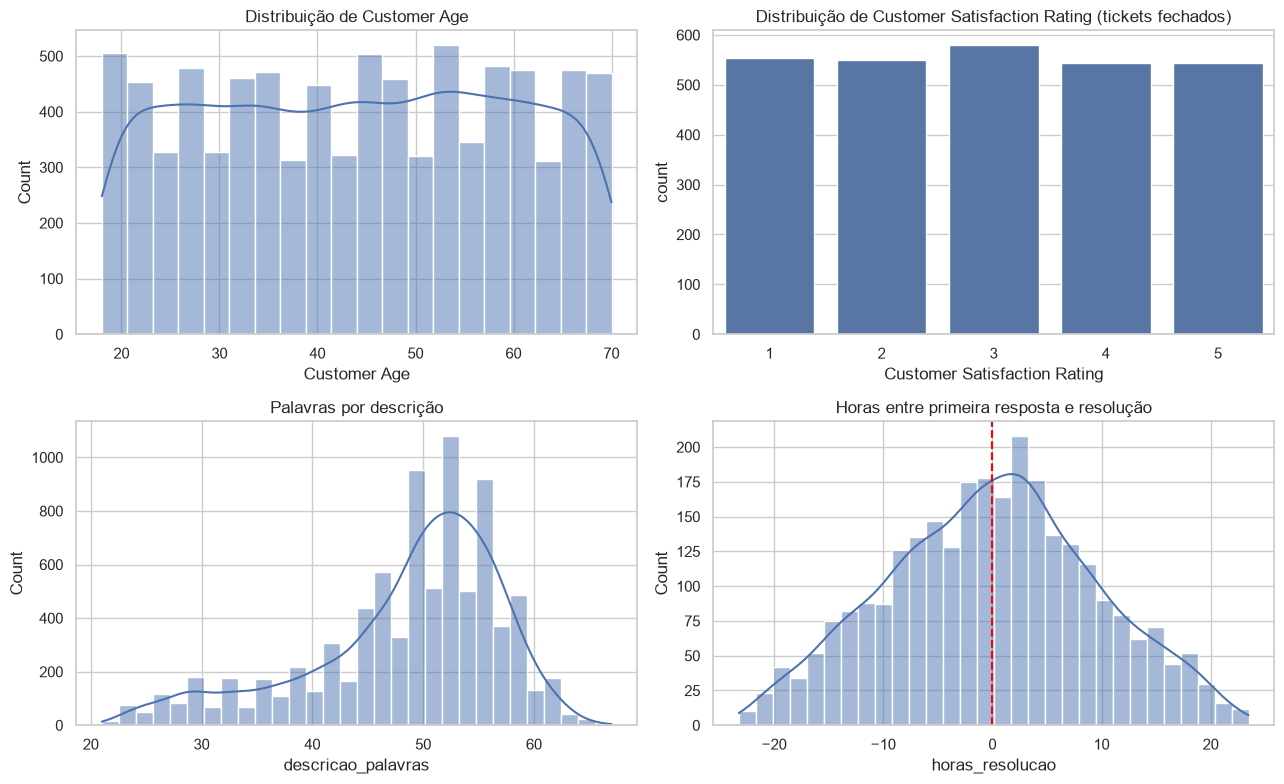

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(df_limpo["Customer Age"], bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribuição de Customer Age")

sns.countplot(x=df_limpo["Customer Satisfaction Rating"].dropna().astype(int), ax=axes[0, 1])
axes[0, 1].set_title("Distribuição de Customer Satisfaction Rating (tickets fechados)")

sns.histplot(df_limpo["descricao_palavras"], bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Palavras por descrição")

sns.histplot(df_limpo["horas_resolucao"].dropna(), bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].axvline(0, color="red", linestyle="--")
axes[1, 1].set_title("Horas entre primeira resposta e resolução")

plt.tight_layout()
plt.show()

**Observações:**

- `Customer Age` tem distribuição **aproximadamente uniforme** entre 18 e 70 anos (assimetria próxima de zero). A variância de cerca de 234 (desvio-padrão de 15,3 anos) é a esperada para uma distribuição uniforme nesse intervalo, sem concentração em nenhuma faixa etária.
- `Customer Satisfaction Rating` também é uniforme: cada nota de 1 a 5 aparece em cerca de 20% dos tickets fechados, com média e mediana em 3. Em um atendimento real seria comum ver concentração em notas altas ou baixas.
- `descricao_palavras` tem distribuição assimétrica à esquerda: metade das descrições tem entre 44 e 55 palavras e existe uma cauda de textos mais curtos, sem nenhum texto muito longo. O desvio-padrão (cerca de 9 palavras) é pequeno perto da média: os textos têm tamanhos muito parecidos, o que também é típico de geração por template.
- `horas_resolucao` vai de cerca de -23 a +23 horas e é simétrica em torno de zero, com metade dos valores negativos. Esse formato confirma que as duas datas foram sorteadas de forma independente (ver 1.7).

### b. Variáveis categóricas — frequência absoluta e relativa

In [24]:
for coluna in ["Ticket Type", "Ticket Priority", "Ticket Channel", "Ticket Status", "Customer Gender"]:
    tabela = pd.DataFrame({
        "frequência": df_limpo[coluna].value_counts(),
        "frequência relativa (%)": (df_limpo[coluna].value_counts(normalize=True) * 100).round(2),
    })
    display(tabela)

,frequência,frequência relativa (%)
Ticket Type,,
Refund request,1752,20.69
Technical issue,1747,20.63
Cancellation request,1695,20.01
Product inquiry,1641,19.38
Billing inquiry,1634,19.29


,frequência,frequência relativa (%)
Ticket Priority,,
Medium,2192,25.88
Critical,2129,25.14
High,2085,24.62
Low,2063,24.36


,frequência,frequência relativa (%)
Ticket Channel,,
Email,2143,25.30
Phone,2132,25.17
Social media,2121,25.04
Chat,2073,24.48


,frequência,frequência relativa (%)
Ticket Status,,
Pending Customer Response,2881,34.02
Open,2819,33.29
Closed,2769,32.70


,frequência,frequência relativa (%)
Customer Gender,,
Male,2896,34.20
Female,2887,34.09
Other,2686,31.72


In [25]:
tabela_assunto = pd.DataFrame({
    "frequência": df_limpo["Ticket Subject"].value_counts(),
    "frequência relativa (%)": (df_limpo["Ticket Subject"].value_counts(normalize=True) * 100).round(2),
})
tabela_assunto

,frequência,frequência relativa (%)
Ticket Subject,,
Refund request,576,6.80
Software bug,574,6.78
Product compatibility,567,6.70
Delivery problem,561,6.62
Hardware issue,547,6.46
Battery life,542,6.40
Network problem,539,6.36
Installation support,530,6.26
Product setup,529,6.25


In [26]:
tabela_produto = pd.DataFrame({
    "frequência": df_limpo["Product Purchased"].value_counts(),
    "frequência relativa (%)": (df_limpo["Product Purchased"].value_counts(normalize=True) * 100).round(2),
})
tabela_produto.head(10)

,frequência,frequência relativa (%)
Product Purchased,,
Sony PlayStation,394,4.65
Canon EOS,240,2.83
GoPro Hero,228,2.69
Nest Thermostat,225,2.66
Philips Hue Lights,221,2.61
Amazon Echo,221,2.61
LG Smart TV,219,2.59
Sony Xperia,217,2.56
Roomba Robot Vacuum,216,2.55


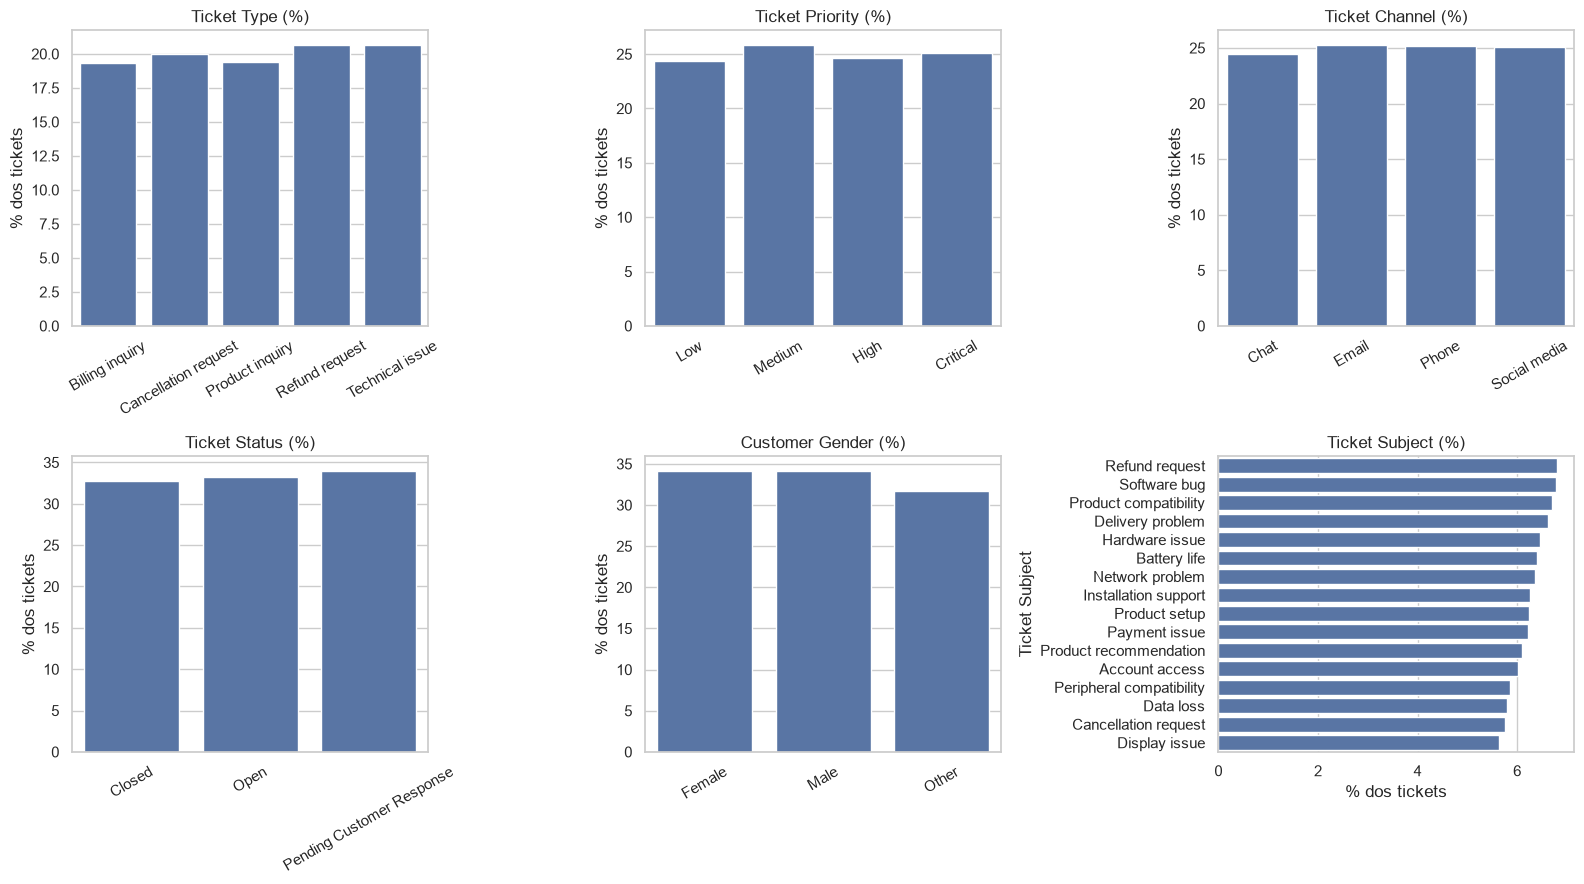

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, coluna in zip(axes.flat, ["Ticket Type", "Ticket Priority", "Ticket Channel",
                                  "Ticket Status", "Customer Gender"]):
    frequencia = df_limpo[coluna].value_counts(normalize=True).sort_index() * 100
    sns.barplot(x=frequencia.index.astype(str), y=frequencia.values, ax=ax)
    ax.set_title(f"{coluna} (%)")
    ax.set_xlabel("")
    ax.set_ylabel("% dos tickets")
    ax.tick_params(axis="x", rotation=30)

frequencia = df_limpo["Ticket Subject"].value_counts(normalize=True) * 100
sns.barplot(x=frequencia.values, y=frequencia.index, ax=axes[1, 2])
axes[1, 2].set_title("Ticket Subject (%)")
axes[1, 2].set_xlabel("% dos tickets")

plt.tight_layout()
plt.show()

**Observações:**

- Todas as categóricas principais têm categorias com frequências relativas muito parecidas. Em `Ticket Type`, por exemplo, cada tipo fica entre 19,3% e 20,7% dos tickets. O mesmo acontece com prioridade (cerca de 25% cada), canal (cerca de 25% cada), status (cerca de 33% cada) e gênero.
- `Ticket Subject` tem 16 assuntos e cada um representa entre 5,6% e 6,8% dos tickets.
- `Product Purchased`, após a unificação do PlayStation, tem 41 produtos. Quase todos ficam entre 2,1% e 2,8% dos tickets, e só a `Sony PlayStation` se destaca (4,7%), justamente por ter somado os dois nomes.

Distribuições tão equilibradas em todas as variáveis são raras em dados reais de suporte, onde normalmente há bem mais tickets de prioridade baixa que críticos ou um canal claramente preferido. É mais um indício de dados gerados artificialmente.

### c. Variável textual — palavras mais frequentes nas descrições

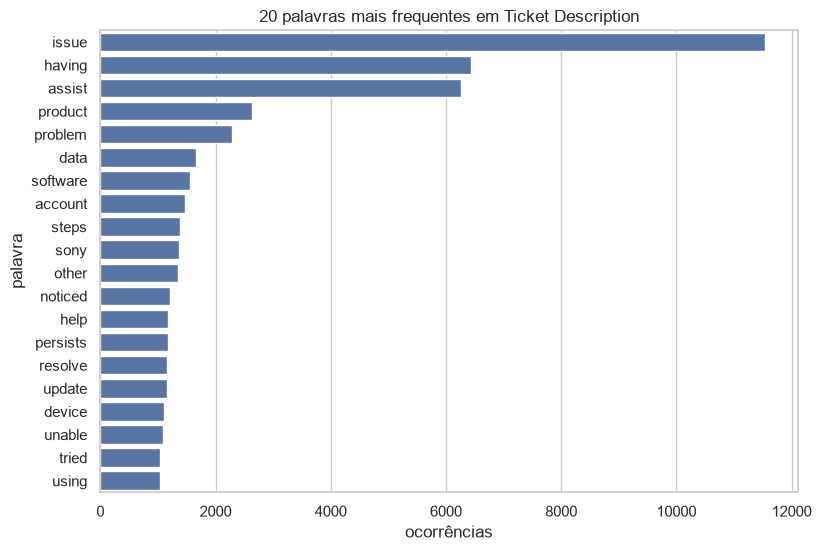

In [28]:
stopwords = {
    "i", "i'm", "i've", "my", "me", "the", "a", "an", "to", "and", "of", "is", "it", "in", "for",
    "with", "on", "this", "that", "be", "you", "your", "have", "has", "but", "not", "can", "please",
    "are", "was", "any", "if", "or", "as", "at", "so", "do", "we", "there", "from", "would", "been",
    "am", "what", "how", "all", "will", "also", "out", "by", "they", "their", "which", "its", "it's",
    "about", "into", "when", "had", "were", "one", "just", "should", "could", "than", "some", "more",
}

palavras = Counter(
    palavra
    for texto in df_limpo["Ticket Description"].str.lower()
    for palavra in re.findall(r"[a-z']+", texto)
    if palavra not in stopwords and len(palavra) > 2
)

top_palavras = pd.DataFrame(palavras.most_common(20), columns=["palavra", "ocorrências"])

plt.figure(figsize=(9, 6))
sns.barplot(data=top_palavras, x="ocorrências", y="palavra")
plt.title("20 palavras mais frequentes em Ticket Description")
plt.show()

As palavras mais frequentes ("issue", "product", "assist", "steps", "troubleshooting", "persists"...) vêm das frases fixas dos templates, como "I'm having an issue with the ... Please assist." e "I've tried troubleshooting steps mentioned in the user manual, but the issue persists." Elas aparecem em praticamente todos os tickets, independentemente do tipo, então carregam pouca informação sobre a intenção do cliente.

## 1.6 Análise Multivariada

### a. Correlação entre as variáveis numéricas

Usamos Pearson (relação linear) e Spearman (relação monotônica, mais adequada para a nota de satisfação, que é ordinal). As correlações com `horas_resolucao` e `Customer Satisfaction Rating` são calculadas apenas nos tickets fechados, onde essas variáveis existem.

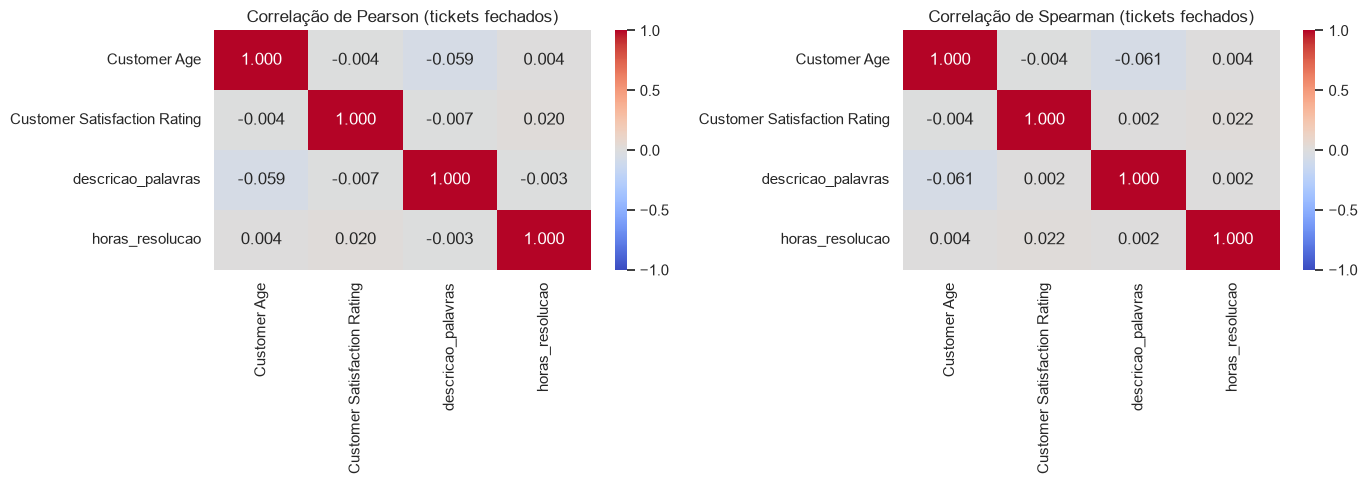

In [29]:
fechados = df_limpo[df_limpo["Ticket Status"] == "Closed"]
colunas_correlacao = ["Customer Age", "Customer Satisfaction Rating", "descricao_palavras", "horas_resolucao"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metodo in zip(axes, ["pearson", "spearman"]):
    sns.heatmap(fechados[colunas_correlacao].corr(method=metodo), annot=True, fmt=".3f",
                cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
    ax.set_title(f"Correlação de {metodo.capitalize()} (tickets fechados)")
plt.tight_layout()
plt.show()

Todas as correlações ficam muito próximas de zero (nenhuma passa de 0,06 em módulo). Não há relação linear nem monotônica entre idade, satisfação, tamanho da descrição e tempo de resolução. Por exemplo, clientes mais velhos não dão notas diferentes, e tickets resolvidos mais rápido não recebem notas melhores.

### b. Cruzamentos entre variáveis categóricas

Para cada cruzamento, a tabela é normalizada por linha (percentual dentro de cada categoria da linha). Se as variáveis fossem associadas, as linhas teriam perfis diferentes.

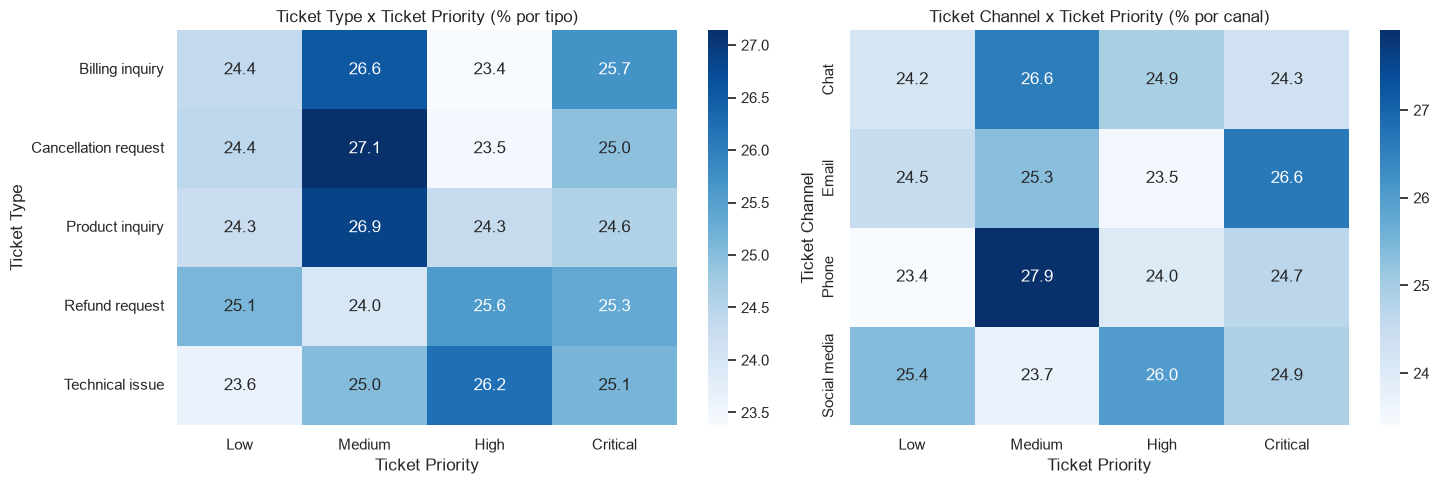

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

tabela = pd.crosstab(df_limpo["Ticket Type"], df_limpo["Ticket Priority"], normalize="index") * 100
sns.heatmap(tabela, annot=True, fmt=".1f", cmap="Blues", ax=axes[0])
axes[0].set_title("Ticket Type x Ticket Priority (% por tipo)")

tabela = pd.crosstab(df_limpo["Ticket Channel"], df_limpo["Ticket Priority"], normalize="index") * 100
sns.heatmap(tabela, annot=True, fmt=".1f", cmap="Blues", ax=axes[1])
axes[1].set_title("Ticket Channel x Ticket Priority (% por canal)")

plt.tight_layout()
plt.show()

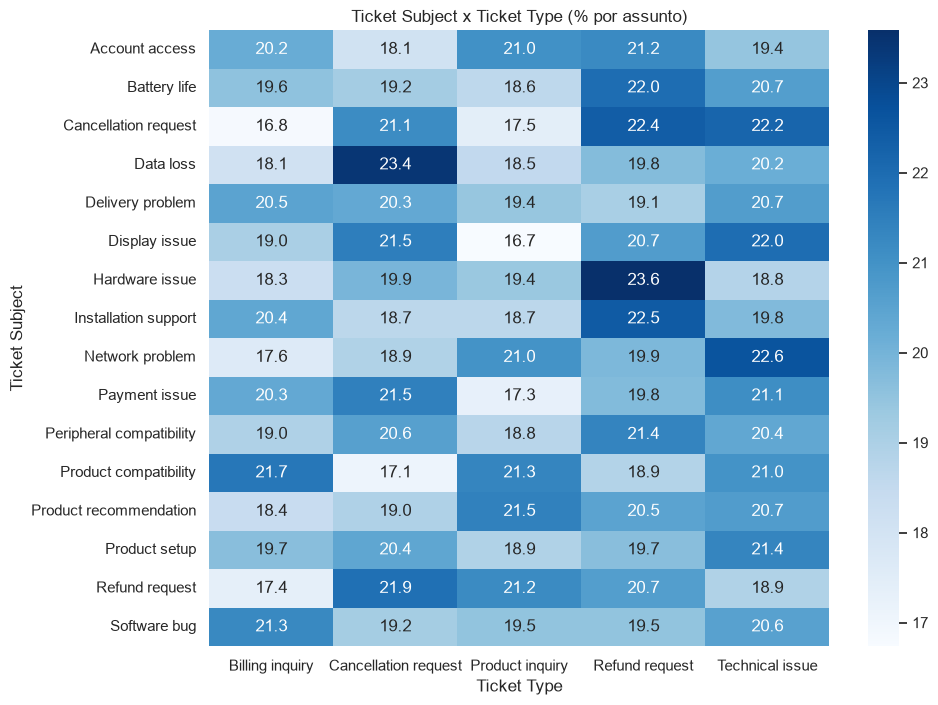

In [31]:
tabela = pd.crosstab(df_limpo["Ticket Subject"], df_limpo["Ticket Type"], normalize="index") * 100

plt.figure(figsize=(10, 8))
sns.heatmap(tabela, annot=True, fmt=".1f", cmap="Blues")
plt.title("Ticket Subject x Ticket Type (% por assunto)")
plt.show()

Os percentuais são parecidos em todas as linhas. O cruzamento entre `Ticket Subject` e `Ticket Type` chama atenção: tickets com assunto `Refund request` se dividem quase igualmente entre os cinco tipos (incluindo `Technical issue` e `Product inquiry`), e o assunto `Cancellation request` não aparece mais vezes no tipo `Cancellation request`. Em dados reais o assunto e o tipo do ticket seriam fortemente relacionados.

Para não depender só da leitura visual, aplicamos o teste qui-quadrado de independência a cada cruzamento, junto com o V de Cramér, que mede a força da associação (0 = nenhuma, 1 = total).

In [32]:
def qui_quadrado(coluna_a, coluna_b, dados=df_limpo):
    tabela = pd.crosstab(dados[coluna_a], dados[coluna_b])
    resultado = stats.chi2_contingency(tabela)
    n = tabela.to_numpy().sum()
    v_cramer = np.sqrt(resultado.statistic / (n * (min(tabela.shape) - 1)))
    return {"cruzamento": f"{coluna_a} x {coluna_b}", "qui-quadrado": round(resultado.statistic, 2),
            "gl": resultado.dof, "p-valor": round(resultado.pvalue, 4), "V de Cramér": round(v_cramer, 3)}

cruzamentos = [("Ticket Type", "Ticket Subject"), ("Ticket Type", "Ticket Priority"),
               ("Ticket Type", "Ticket Channel"), ("Ticket Type", "Product Purchased"),
               ("Ticket Type", "Customer Gender"), ("Ticket Type", "faixa_etaria"),
               ("Ticket Channel", "Ticket Priority")]

pd.DataFrame([qui_quadrado(a, b) for a, b in cruzamentos])

,cruzamento,qui-quadrado,gl,p-valor,V de Cramér
0,Ticket Type x Ticket Subject,39.57,60,0.9807,0.034
1,Ticket Type x Ticket Priority,10.63,12,0.5613,0.020
2,Ticket Type x Ticket Channel,11.85,12,0.4578,0.022
3,Ticket Type x Product Purchased,123.24,160,0.9861,0.060
4,Ticket Type x Customer Gender,5.85,8,0.6641,0.019
5,Ticket Type x faixa_etaria,34.83,16,0.0042,0.032
6,Ticket Channel x Ticket Priority,15.48,9,0.0785,0.025


Com nível de significância de 5%, **seis dos sete cruzamentos não rejeitam a hipótese de independência**. Isso vale inclusive para `Ticket Type x Ticket Subject` (p = 0,98), que deveriam ser as variáveis mais ligadas entre si, e para `Ticket Channel x Ticket Priority` (p = 0,079).

A exceção é **`Ticket Type x faixa_etaria` (p = 0,004)**. Como foram feitos sete testes, a chance de pelo menos um dar significativo por acaso não é desprezível. Mesmo assim, o resultado continua significativo com a correção de Bonferroni (0,05 / 7 ≈ 0,007), então vale investigar. Todos os V de Cramér ficam abaixo de 0,1, inclusive esse (0,032): mesmo quando existe, a associação é muito fraca.

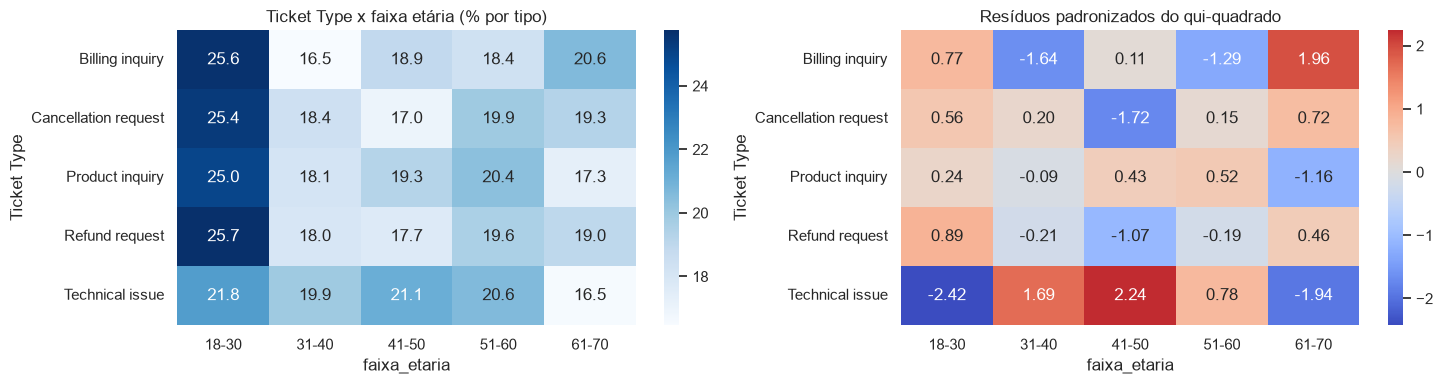

In [33]:
tabela = pd.crosstab(df_limpo["Ticket Type"], df_limpo["faixa_etaria"])
esperado = stats.chi2_contingency(tabela).expected_freq
residuos = (tabela - esperado) / np.sqrt(esperado)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.heatmap(pd.crosstab(df_limpo["Ticket Type"], df_limpo["faixa_etaria"], normalize="index") * 100,
            annot=True, fmt=".1f", cmap="Blues", ax=axes[0])
axes[0].set_title("Ticket Type x faixa etária (% por tipo)")
sns.heatmap(residuos, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Resíduos padronizados do qui-quadrado")
plt.tight_layout()
plt.show()

Os resíduos padronizados mostram de onde vem a diferença: os tickets `Technical issue` têm **menos clientes de 18 a 30 anos** (21,8%, contra cerca de 25% nos demais tipos) e de 61 a 70 anos, e **mais clientes de 31 a 50 anos** que o esperado. Ou seja, a idade de quem abre problemas técnicos é mais concentrada no meio da faixa. Essa diferença é retomada na hipótese H1.

### c. Variáveis numéricas por grupo

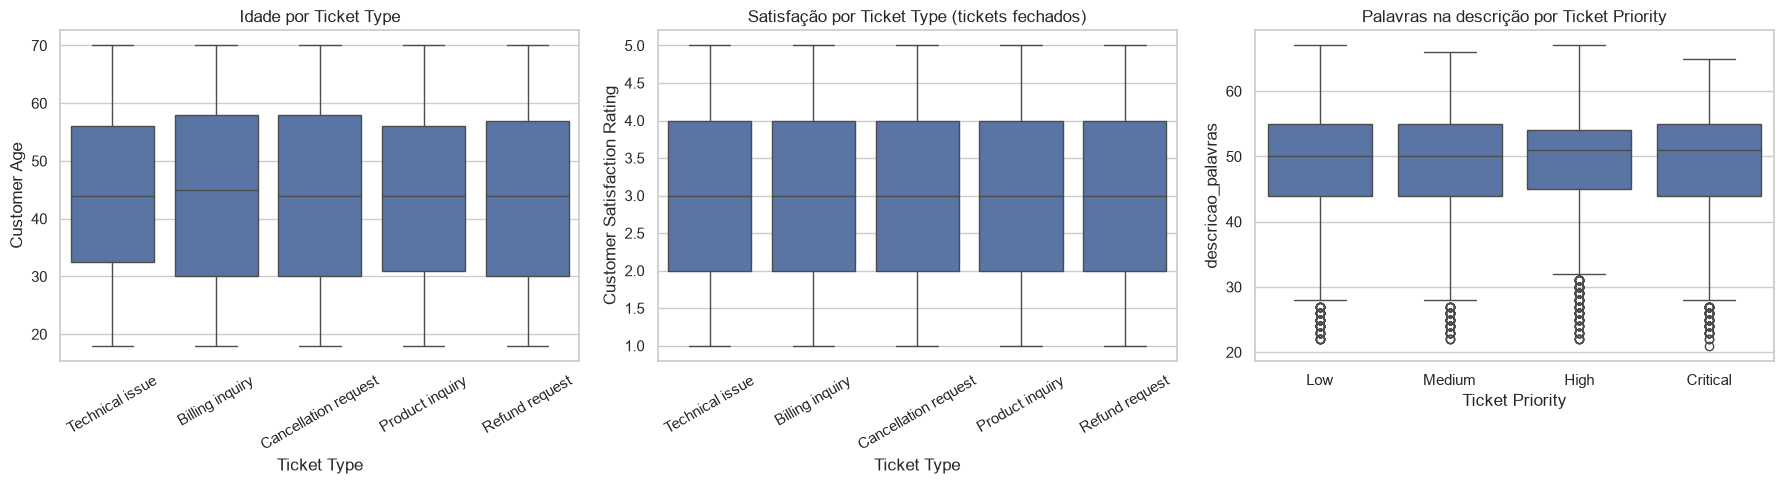

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_limpo, x="Ticket Type", y="Customer Age", ax=axes[0])
axes[0].set_title("Idade por Ticket Type")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=fechados, x="Ticket Type", y="Customer Satisfaction Rating", ax=axes[1])
axes[1].set_title("Satisfação por Ticket Type (tickets fechados)")
axes[1].tick_params(axis="x", rotation=30)

sns.boxplot(data=df_limpo, x="Ticket Priority", y="descricao_palavras", ax=axes[2])
axes[2].set_title("Palavras na descrição por Ticket Priority")

plt.tight_layout()
plt.show()

In [35]:
pd.concat({
    "idade média": df_limpo.groupby("Ticket Type")["Customer Age"].mean(),
    "satisfação média": fechados.groupby("Ticket Type")["Customer Satisfaction Rating"].mean(),
    "tickets fechados": fechados.groupby("Ticket Type").size(),
}, axis=1).round(2)

,idade média,satisfação média,tickets fechados
Ticket Type,,,
Billing inquiry,44.25,3.03,544
Cancellation request,44.05,3.03,516
Product inquiry,43.76,3.02,533
Refund request,43.94,2.93,596
Technical issue,44.14,2.96,580


As caixas dos boxplots estão praticamente alinhadas: as medianas de idade ficam em torno de 44 anos para todos os tipos, a mediana de satisfação é 3 em todos os tipos e as descrições têm o mesmo tamanho em todas as prioridades. As maiores diferenças de média são pequenas (por exemplo, a satisfação média de `Refund request` é 2,94, contra 3,03 de `Billing inquiry`). Os testes da próxima seção verificam se essas diferenças são estatisticamente significativas.

### d. Hipóteses e testes formais

No TP1, as hipóteses foram levantadas a partir da análise univariada. O argumento usado era que, como as distribuições de duas variáveis eram aproximadamente uniformes, elas não deveriam estar associadas. **Esse raciocínio não é válido**: as distribuições univariadas (marginais) não dizem nada sobre a relação entre as variáveis. Duas variáveis uniformes podem ser totalmente dependentes. Por exemplo, se todo ticket `Critical` fosse aberto por telefone, as duas distribuições continuariam uniformes. A associação só pode ser avaliada **cruzando as variáveis**.

Por isso as hipóteses foram reformuladas, indicando para cada uma o cruzamento necessário e o teste formal usado.

| Hipótese | Pergunta | Cruzamento necessário | Teste |
|---|---|---|---|
| H1 (TP1 hip. 1) | O perfil do cliente (idade) muda conforme a intenção do ticket? | `Customer Age` x `Ticket Type` | Mann-Whitney / t-test de Welch entre `Refund request` e `Technical issue` |
| H2 (TP1 hip. 3) | A satisfação depende da natureza da solicitação? | `Customer Satisfaction Rating` x `Ticket Type` (tickets fechados) | Mann-Whitney entre `Refund request` e `Product inquiry` |
| H3 (TP1 hip. 2) | A urgência do ticket se reflete na forma como o cliente se comunica? | `descricao_palavras` x `Ticket Priority` e `Ticket Channel` x `Ticket Priority` | Mann-Whitney unilateral entre `Critical` e `Low` + qui-quadrado (seção b) |

Os pares de grupos foram escolhidos **antes** de olhar os resultados, pela relevância para o negócio:
- **H1:** pedidos de reembolso (cliente que quer devolver o produto) contra problemas técnicos (cliente que quer continuar usando).
- **H2:** reembolso (situação de conflito) contra dúvida sobre produto (situação neutra).
- **H3:** os dois extremos de prioridade.

**Escolha do teste:** para cada par, verificamos a normalidade dos dois grupos com o teste de D'Agostino-Pearson (`scipy.stats.normaltest`, adequado para amostras grandes).
- Se os dois grupos forem normais, usamos o **t-test de Welch**, que não assume variâncias iguais.
- Caso contrário, usamos o **Mann-Whitney U**, que não exige normalidade.
- A nota de satisfação é ordinal (1 a 5), então nesse caso o Mann-Whitney é usado diretamente.

O nível de significância é α = 0,05.

In [36]:
ALFA = 0.05

def comparar_grupos(grupo_a, grupo_b, nome_a, nome_b, alternativa="two-sided", ordinal=False):
    grupo_a, grupo_b = grupo_a.dropna(), grupo_b.dropna()

    p_normal_a = stats.normaltest(grupo_a).pvalue
    p_normal_b = stats.normaltest(grupo_b).pvalue
    normais = p_normal_a > ALFA and p_normal_b > ALFA

    if normais and not ordinal:
        teste = "t-test de Welch"
        resultado = stats.ttest_ind(grupo_a, grupo_b, equal_var=False, alternative=alternativa)
    else:
        teste = "Mann-Whitney U"
        resultado = stats.mannwhitneyu(grupo_a, grupo_b, alternative=alternativa)

    print(f"{nome_a}: n={len(grupo_a)}, média={grupo_a.mean():.2f}, mediana={grupo_a.median():.1f}, "
          f"p-normalidade={p_normal_a:.2e}")
    print(f"{nome_b}: n={len(grupo_b)}, média={grupo_b.mean():.2f}, mediana={grupo_b.median():.1f}, "
          f"p-normalidade={p_normal_b:.2e}")
    print(f"Teste: {teste} ({alternativa}) | estatística={resultado.statistic:.2f} | p-valor={resultado.pvalue:.4f}")
    print("Conclusão:", "rejeita H0" if resultado.pvalue < ALFA else "não rejeita H0", f"(α = {ALFA})")
    return resultado.pvalue

#### H1 — A idade do cliente é diferente entre pedidos de reembolso e problemas técnicos?

- **H0:** a distribuição de idade é a mesma nos tickets `Refund request` e `Technical issue`.
- **H1:** a distribuição de idade é diferente entre os dois tipos (bilateral).

In [37]:
p_h1 = comparar_grupos(
    df_limpo.loc[df_limpo["Ticket Type"] == "Refund request", "Customer Age"],
    df_limpo.loc[df_limpo["Ticket Type"] == "Technical issue", "Customer Age"],
    "Refund request", "Technical issue",
)

# Como os grupos são grandes, o t-test de Welch também é válido pelo Teorema Central do Limite.
# Ele é mostrado apenas para confirmar que a conclusão não muda com o teste.
welch = stats.ttest_ind(
    df_limpo.loc[df_limpo["Ticket Type"] == "Refund request", "Customer Age"],
    df_limpo.loc[df_limpo["Ticket Type"] == "Technical issue", "Customer Age"],
    equal_var=False,
)
print(f"\nConferência com t-test de Welch: p-valor={welch.pvalue:.4f}")

Refund request: n=1752, média=43.94, mediana=44.0, p-normalidade=0.00e+00
Technical issue: n=1747, média=44.14, mediana=44.0, p-normalidade=1.97e-132
Teste: Mann-Whitney U (two-sided) | estatística=1519860.50 | p-valor=0.7249
Conclusão: não rejeita H0 (α = 0.05)

Conferência com t-test de Welch: p-valor=0.6994


A idade não segue distribuição normal (é uniforme, como visto na 1.5), então foi usado o Mann-Whitney. O p-valor ficou bem acima de 0,05 e a diferença de médias entre os grupos é menor que meio ano. **Não rejeitamos H0**: a idade típica de quem pede reembolso e de quem relata problema técnico é a mesma. O t-test de Welch leva à mesma conclusão.

Esse resultado parece contradizer o qui-quadrado `Ticket Type x faixa_etaria` da seção b, mas os testes medem coisas diferentes. O Mann-Whitney e o t-test comparam a **posição** das distribuições (mediana e média). O qui-quadrado detecta qualquer diferença no **formato**. Para conferir, comparamos a dispersão da idade por tipo e aplicamos o teste de Kolmogorov-Smirnov, que compara a distribuição inteira, entre `Technical issue` e os demais tipos.

In [38]:
print(df_limpo.groupby("Ticket Type")["Customer Age"].agg(["mean", "median", "std"]).round(2))

tecnico = df_limpo["Ticket Type"] == "Technical issue"
ks = stats.ks_2samp(df_limpo.loc[tecnico, "Customer Age"], df_limpo.loc[~tecnico, "Customer Age"])
print(f"\nKolmogorov-Smirnov (Technical issue x demais tipos): estatística={ks.statistic:.4f}, p-valor={ks.pvalue:.4f}")
print("Kruskal-Wallis (idade entre os 5 tipos): p-valor =",
      round(stats.kruskal(*[g["Customer Age"] for _, g in df_limpo.groupby("Ticket Type")]).pvalue, 4))

                       mean  median    std
Ticket Type                               
Billing inquiry       44.25    45.0  15.63
Cancellation request  44.05    44.0  15.53
Product inquiry       43.76    44.0  15.22
Refund request        43.94    44.0  15.42
Technical issue       44.14    44.0  14.71

Kolmogorov-Smirnov (Technical issue x demais tipos): estatística=0.0396, p-valor=0.0249
Kruskal-Wallis (idade entre os 5 tipos): p-valor = 0.9097


A média e a mediana são praticamente iguais em todos os tipos, e o Kruskal-Wallis, que compara a posição entre os 5 tipos de uma vez, também não é significativo. Já o desvio-padrão de `Technical issue` é menor (cerca de 14,7 anos, contra 15,2 a 15,6 nos demais), e o Kolmogorov-Smirnov aponta diferença de distribuição ao nível de 5%.

**Conclusão da H1:** a idade típica não muda com a intenção do ticket, mas quem abre problemas técnicos tem idades um pouco mais concentradas na faixa de 31 a 50 anos. O efeito é muito pequeno (V de Cramér de 0,032 e estatística KS de 0,04) e não serve, sozinho, para diferenciar as intenções.

#### H2 — A satisfação é diferente entre pedidos de reembolso e dúvidas sobre produto?

- **H0:** a distribuição das notas de satisfação é a mesma nos tickets fechados de `Refund request` e `Product inquiry`.
- **H1:** a distribuição das notas é diferente entre os dois tipos (bilateral).

In [39]:
p_h2 = comparar_grupos(
    fechados.loc[fechados["Ticket Type"] == "Refund request", "Customer Satisfaction Rating"],
    fechados.loc[fechados["Ticket Type"] == "Product inquiry", "Customer Satisfaction Rating"],
    "Refund request", "Product inquiry",
    ordinal=True,
)

Refund request: n=596, média=2.93, mediana=3.0, p-normalidade=4.45e-244
Product inquiry: n=533, média=3.02, mediana=3.0, p-normalidade=8.23e-77
Teste: Mann-Whitney U (two-sided) | estatística=153495.00 | p-valor=0.3191
Conclusão: não rejeita H0 (α = 0.05)


Os pedidos de reembolso têm nota média um pouco menor que as dúvidas sobre produto, mas a mediana é 3 nos dois grupos e o p-valor está acima de 0,05. **Não rejeitamos H0**: a natureza da solicitação não está associada à satisfação do cliente neste dataset. O resultado é coerente com o boxplot da seção c, em que a mediana de satisfação é 3 para todos os tipos, e com a correlação praticamente zero entre a satisfação e as demais variáveis numéricas.

#### H3 — Tickets críticos têm descrições mais longas que tickets de baixa prioridade?

A ideia é que, se a urgência refletisse a experiência real do cliente, um problema crítico tenderia a ser descrito com mais detalhes. A outra metade dessa hipótese (o canal escolhido depender da prioridade) já foi testada com o qui-quadrado na seção b: `Ticket Channel x Ticket Priority` teve p-valor de 0,079, sem associação significativa.

- **H0:** o número de palavras das descrições de tickets `Critical` não é maior que o de tickets `Low`.
- **H1:** as descrições de tickets `Critical` têm mais palavras que as de tickets `Low` (unilateral).

In [40]:
p_h3 = comparar_grupos(
    df_limpo.loc[df_limpo["Ticket Priority"] == "Critical", "descricao_palavras"],
    df_limpo.loc[df_limpo["Ticket Priority"] == "Low", "descricao_palavras"],
    "Critical", "Low",
    alternativa="greater",
)

Critical: n=2129, média=48.39, mediana=51.0, p-normalidade=2.58e-55
Low: n=2063, média=48.12, mediana=50.0, p-normalidade=1.50e-50
Teste: Mann-Whitney U (greater) | estatística=2229943.00 | p-valor=0.1933
Conclusão: não rejeita H0 (α = 0.05)


O tamanho das descrições não é normal (assimetria negativa), então foi usado o Mann-Whitney unilateral. As medianas dos dois grupos são quase iguais e o p-valor está acima de 0,05. **Não rejeitamos H0**: tickets críticos não são descritos com mais detalhes que os de baixa prioridade. Junto com o qui-quadrado entre canal e prioridade, isso indica que a urgência do ticket não se reflete na forma como o cliente se comunica.

In [41]:
pd.DataFrame({
    "hipótese": ["H1 - idade x tipo", "H2 - satisfação x tipo", "H3 - tamanho da descrição x prioridade"],
    "teste": ["Mann-Whitney U (bilateral)", "Mann-Whitney U (bilateral)", "Mann-Whitney U (unilateral)"],
    "p-valor": [round(p_h1, 4), round(p_h2, 4), round(p_h3, 4)],
    "conclusão (α = 0,05)": ["não rejeita H0" if p >= ALFA else "rejeita H0" for p in [p_h1, p_h2, p_h3]],
})

,hipótese,teste,p-valor,"conclusão (α = 0,05)"
0,H1 - idade x tipo,Mann-Whitney U (bilateral),0.7249,não rejeita H0
1,H2 - satisfação x tipo,Mann-Whitney U (bilateral),0.3191,não rejeita H0
2,H3 - tamanho da descrição x prioridade,Mann-Whitney U (unilateral),0.1933,não rejeita H0


## 1.7 Identificação de Outliers e Anomalias

### a. Outliers estatísticos

Usamos dois critérios para as variáveis numéricas:
- **IQR:** valores abaixo de Q1 - 1,5·IQR ou acima de Q3 + 1,5·IQR;
- **z-score:** valores a mais de 3 desvios-padrão da média.

In [42]:
def contar_outliers(serie):
    serie = serie.dropna()
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inferior, limite_superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    z = np.abs(stats.zscore(serie))
    return {
        "Q1": q1, "Q3": q3, "limite inferior": limite_inferior, "limite superior": limite_superior,
        "outliers IQR": ((serie < limite_inferior) | (serie > limite_superior)).sum(),
        "outliers z > 3": (z > 3).sum(),
    }

pd.DataFrame({coluna: contar_outliers(df_limpo[coluna]) for coluna in colunas_numericas}).T.round(2)

,Q1,Q3,limite inferior,limite superior,outliers IQR,outliers z > 3
Customer Age,31.00,57.00,-8.00,96.00,0.0,0.0
Customer Satisfaction Rating,2.00,4.00,-1.00,7.00,0.0,0.0
descricao_palavras,44.00,55.00,27.50,71.50,258.0,17.0
descricao_caracteres,258.00,308.00,183.00,383.00,491.0,17.0
horas_resolucao,-6.93,6.48,-27.06,26.61,0.0,0.0


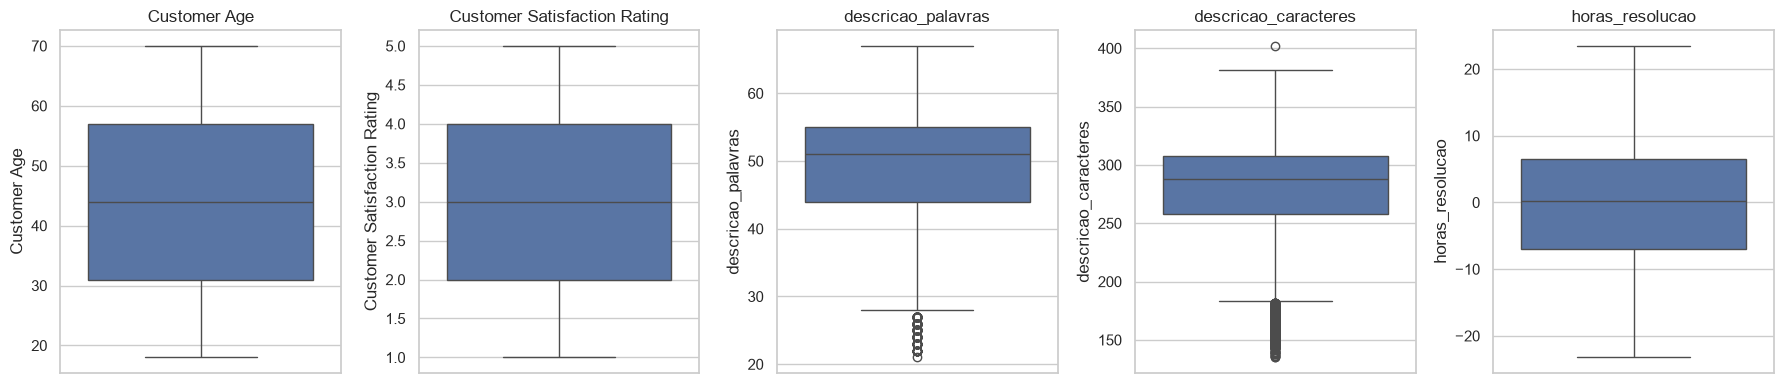

In [43]:
fig, axes = plt.subplots(1, len(colunas_numericas), figsize=(18, 4))
for ax, coluna in zip(axes, colunas_numericas):
    sns.boxplot(y=df_limpo[coluna], ax=ax)
    ax.set_title(coluna)
plt.tight_layout()
plt.show()

In [44]:
limite = contar_outliers(df_limpo["descricao_palavras"])["limite inferior"]
curtas = df_limpo[df_limpo["descricao_palavras"] < limite]

print(f"Descrições abaixo do limite de {limite:.1f} palavras: {len(curtas)}")
print(curtas["Ticket Type"].value_counts(normalize=True).round(3).to_dict())
curtas["Ticket Description"].head(3).tolist()

Descrições abaixo do limite de 27.5 palavras: 258
{'Cancellation request': 0.24, 'Technical issue': 0.233, 'Refund request': 0.186, 'Billing inquiry': 0.186, 'Product inquiry': 0.155}


["I'm having an issue with the Nest Thermostat. Please assist. Please. Please. I need assistance as soon as possible because it's affecting my work and productivity.",
 "I'm having an issue with the Microsoft Xbox Controller. Please assist. http://www.kyle@junebug.com/tutorial/cure-all- I've tried troubleshooting steps mentioned in the user manual, but the issue persists.",
 "I'm having an issue with the Dyson Vacuum Cleaner. Please assist. I need assistance as soon as possible because it's affecting my work and productivity."]

- `Customer Age`, `Customer Satisfaction Rating` e `horas_resolucao` não têm outliers por nenhum dos dois critérios. Isso é esperado para variáveis uniformes e limitadas, porque não existem caudas longas.
- `descricao_palavras` e `descricao_caracteres` têm outliers pelo critério do IQR, quase todos **inferiores**: descrições bem mais curtas que as demais. Pelo z-score, que é menos sensível em distribuições assimétricas, são poucos casos. Lendo esses textos, eles são válidos (o mesmo template com menos frases) e aparecem em todos os tipos de ticket, sem se concentrar em um só. Não são erros, então **foram mantidos**.

### b. Anomalias de negócio

Os principais problemas do dataset não aparecem como outliers estatísticos, mas como valores que não fazem sentido no contexto do negócio.

Tickets fechados: 2769
Resolvidos antes da primeira resposta: 1365 (49.3%)


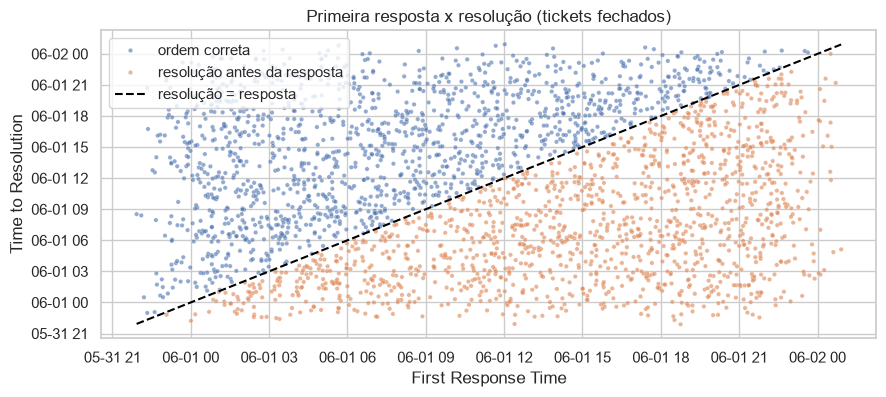

In [45]:
fechados = df_limpo[df_limpo["Ticket Status"] == "Closed"]
negativos = fechados["horas_resolucao"] < 0

print(f"Tickets fechados: {len(fechados)}")
print(f"Resolvidos antes da primeira resposta: {negativos.sum()} ({negativos.mean() * 100:.1f}%)")

plt.figure(figsize=(10, 4))
sns.scatterplot(x=fechados["First Response Time"], y=fechados["Time to Resolution"],
                hue=negativos.map({True: "resolução antes da resposta", False: "ordem correta"}),
                s=10, alpha=0.6)
plt.plot([fechados["First Response Time"].min(), fechados["First Response Time"].max()],
         [fechados["First Response Time"].min(), fechados["First Response Time"].max()],
         color="black", linestyle="--", label="resolução = resposta")
plt.title("Primeira resposta x resolução (tickets fechados)")
plt.legend()
plt.show()

O gráfico mostra que os pontos se espalham igualmente acima e abaixo da diagonal: o momento da resolução não depende do momento da primeira resposta. Isso confirma que as duas datas foram geradas de forma independente e que **qualquer métrica de tempo de atendimento calculada a partir delas não é confiável**. Por isso `horas_resolucao` não foi usada nos testes de hipótese.

Resumo das anomalias encontradas:

| Anomalia | Ocorrências | Tratamento |
|---|---|---|
| Resolução antes da primeira resposta | 1.365 tickets (49% dos fechados) | Registros mantidos; durações não usadas como métrica |
| Datas de resposta e resolução concentradas em ~27 h de 2023, para compras de 2020-2021 | Todos os tickets respondidos | Documentado; datas não usadas como variável preditora |
| Marcador `{product_purchased}` não substituído | 8.469 descrições (100%) | Substituído pelo produto do ticket |
| Outros marcadores de template | 794 descrições, após substituir as variações do marcador de produto | Removidos do texto e registrados em `tem_marcador_template` |
| Tags HTML e URLs soltas no texto | 199 descrições com tags e 235 com URLs | Tags removidas; URLs mantidas |
| Texto de `Resolution` com palavras aleatórias | 2.769 tickets fechados | Coluna não utilizada |
| E-mails repetidos com nomes diferentes | 139 e-mails | Colunas PII removidas |
| Mesmo produto com dois nomes | 394 tickets (`PlayStation` + `Sony PlayStation`) | Unificado |
| Distribuições uniformes e ausência de associação entre praticamente todas as variáveis, inclusive `Ticket Type` x `Ticket Subject` | Base inteira | Documentado nas conclusões |

## 1.8 Documentação do EDA e conclusões

### Decisões de limpeza e preparação

- As datas foram convertidas para `datetime`, e as categóricas foram padronizadas (sem impacto, porque não havia inconsistências de grafia).
- `PlayStation` e `Sony PlayStation` foram unificados.
- As descrições tiveram o marcador `{product_purchased}` (e suas variações) substituído pelo produto, os demais marcadores e as tags HTML removidos e os espaços normalizados.
- Os dados pessoais (`Customer Name` e `Customer Email`) foram removidos da base de análise.
- Os valores ausentes foram mantidos, porque são estruturais e dependem do `Ticket Status`.
- Foram criadas as variáveis `descricao_palavras`, `descricao_caracteres`, `horas_resolucao` e `faixa_etaria`.
- Não foram removidos outliers: os únicos encontrados (descrições curtas) são textos válidos.

### Resultado dos testes de hipótese

Nos testes formais (Mann-Whitney), nenhuma das três hipóteses mostrou diferença significativa ao nível de 5%:

- **H1:** a idade típica não difere entre pedidos de reembolso e problemas técnicos. A investigação complementar mostrou só uma diferença de dispersão muito pequena: quem abre `Technical issue` tem idade um pouco mais concentrada entre 31 e 50 anos (qui-quadrado com faixa etária e Kolmogorov-Smirnov significativos, mas com efeito desprezível).
- **H2:** a satisfação não difere entre pedidos de reembolso e dúvidas sobre produto.
- **H3:** tickets críticos não têm descrições mais longas que os de baixa prioridade, e o canal também não está associado à prioridade (qui-quadrado).

No TP1, essas hipóteses eram suposições baseadas apenas nas distribuições univariadas. Agora a conclusão vem dos cruzamentos entre as variáveis e de testes estatísticos. O caso da idade mostra por que isso importa: olhando só o histograma uniforme da idade, não daria para perceber a diferença de formato que existe dentro de um dos tipos de ticket.

### Conclusões sobre o dataset

1. **Os dados têm forte indício de serem sintéticos:**
   - todas as categóricas são uniformes;
   - quase nenhum cruzamento apresenta associação (nem `Ticket Type` x `Ticket Subject`);
   - as descrições são geradas por template, com marcadores não substituídos;
   - as datas de atendimento ficam numa janela de 27 horas, com metade das resoluções antes da primeira resposta;
   - o texto de `Resolution` é aleatório.
2. **As variáveis estruturadas praticamente não ajudam a prever a intenção do cliente.** Gênero, produto, canal e prioridade são independentes de `Ticket Type`, e a única associação encontrada (faixa etária) é fraca demais para ser útil. Um modelo que usasse só essas colunas teria desempenho próximo ao acaso (cerca de 20% de acerto para 5 tipos).
3. **As métricas de tempo não são confiáveis** e não devem ser usadas como variável nem como indicador de qualidade do atendimento.

### Implicações para os próximos TPs

- Para o modelo de classificação de intenção que será servido pela rota `/predictions/predict`, a fonte de informação mais promissora é o **texto** (`Ticket Description`), já limpo nesta etapa. Mesmo assim, como as descrições vêm de templates genéricos, existe o risco de o texto também não separar bem as classes. Isso precisa ser medido logo no início do treinamento, comparando o modelo com uma linha de base que sempre prevê a classe mais frequente.
- A escolha da variável-alvo precisa ser revista: como `Ticket Type` e `Ticket Subject` são independentes, eles não podem ser tratados como versões "geral" e "detalhada" da mesma intenção.
- Se o desempenho for próximo ao acaso, uma alternativa é complementar o dataset com exemplos de texto rotulados manualmente para as intenções que a API precisa reconhecer.